# Autocorrelation (ACF & PACF)

In Lesson 02, we learned how to mathematically extract the broad Trend and repeating Seasonality from a Time Series. But what happens to the data that is left over?

Even after removing the obvious patterns, time series data often contains a hidden "memory." What happened yesterday still exerts a gravitational pull on what happens today. To measure the exact strength and length of this memory, we must use **Autocorrelation**.

Mastering the ACF and PACF charts is non-negotiable for enterprise forecasting; they are the literal blueprints required to build classic models like ARIMA.

"Auto" means self. Autocorrelation is simply the mathematical correlation of a time series with its own past.

Let's set up our Python environment to measure the memory of a dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Autocorrelation Diagnostics Environment Ready.")

✅ Autocorrelation Diagnostics Environment Ready.


# 1. The Mathematics of Lags

To correlate a time series with itself, we must mathematically shift it backward in time. This shift is called a **Lag ($k$)**.

* **$y_t$**: The data today.
* **$y_{t-1}$**: Lag 1 (The data yesterday).
* **$y_{t-k}$**: Lag $k$ (The data $k$ steps ago).

If we want to know if yesterday's sales affect today's sales, we take the original $y_t$ array, shift it down by 1 row to create $y_{t-1}$, and calculate the standard Pearson Correlation Coefficient between the two columns.

# 2. The Autocorrelation Function (ACF)

The **ACF** calculates the correlation between $y_t$ and every possible lag $y_{t-k}$ and plots the results on a bar chart (a Correlogram).

The mathematical formula for the Autocorrelation at lag $k$ is:


$$r_k = \frac{\sum_{t=k+1}^{T} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T} (y_t - \bar{y})^2}$$

### The "Echo" Problem (Indirect Correlation)

ACF has a massive mathematical vulnerability: it captures **indirect correlation** (echoes).
Suppose today's weather ($y_t$) is heavily dependent on yesterday's weather ($y_{t-1}$). And yesterday's weather was heavily dependent on the day before ($y_{t-2}$).

Because of this chain reaction, the ACF will report a high correlation between today ($y_t$) and the day before yesterday ($y_{t-2}$). But the day before yesterday isn't *directly* causing today's weather; the signal is just echoing through yesterday. If we feed both $y_{t-1}$ and $y_{t-2}$ into a machine learning model, we are feeding it highly redundant data, which causes **Multicollinearity**.

# 3. The Partial Autocorrelation Function (PACF)

To solve the echo problem, we use the **PACF**.

The PACF measures the **strict, direct correlation** between $y_t$ and $y_{t-k}$ *after mathematically removing the effects of all the intermediate lags* between them.

* **PACF at Lag 1**: Exactly the same as ACF (there are no intermediate lags).
* **PACF at Lag 2**: Measures the correlation between $y_t$ and $y_{t-2}$, completely ignoring any information that flowed through $y_{t-1}$.
* **The Math**: It is calculated using advanced linear algebra, specifically by fitting a linear regression model of $y_t$ on $y_{t-1}, y_{t-2}, \dots, y_{t-k}$ and extracting the exact coefficient of the final term.

# 4. Visualizing the Correlograms

Let's simulate a time series with a strict **Auto-Regressive** memory. We will explicitly program the data so that today is only influenced by the previous 2 days (Lag 1 and Lag 2). Then, we will plot the ACF and PACF to see if the math can expose our secret.

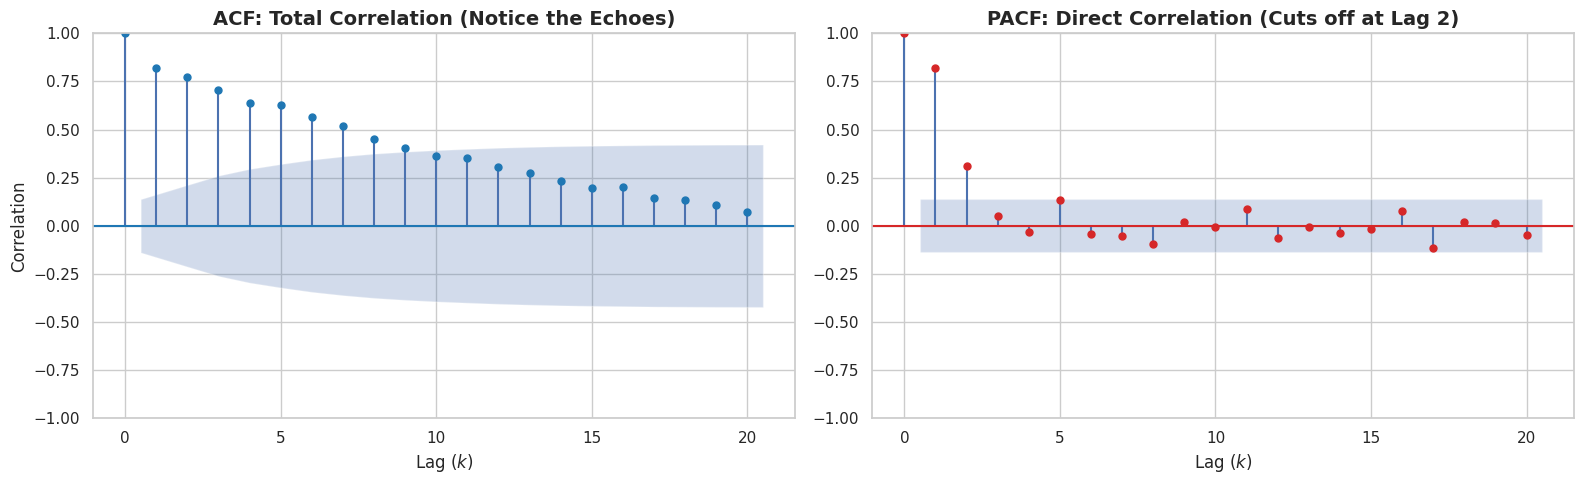

In [2]:
# 1. Simulate an AR(2) Time Series (Memory lasts exactly 2 days)
np.random.seed(42)
n_samples = 200
y = np.zeros(n_samples)

# We define the strict mathematical weights (Phi)
# Today = (0.6 * Yesterday) + (0.3 * Day Before) + Random Noise
phi_1 = 0.6
phi_2 = 0.3

for t in range(2, n_samples):
    y[t] = phi_1 * y[t-1] + phi_2 * y[t-2] + np.random.normal(0, 1)

# 2. Matplotlib Visualization of ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF
# The blue shaded region is the 95% Confidence Interval. 
# Spikes outside this region are statistically significant.
plot_acf(y, lags=20, ax=axes[0], alpha=0.05, color='#1f77b4')
axes[0].set_title("ACF: Total Correlation (Notice the Echoes)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Lag ($k$)")
axes[0].set_ylabel("Correlation")

# Plot PACF
plot_pacf(y, lags=20, ax=axes[1], alpha=0.05, color='#d62728', method='ywm')
axes[1].set_title("PACF: Direct Correlation (Cuts off at Lag 2)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Lag ($k$)")

plt.tight_layout()
plt.show()

*(Insight: Look at the left plot (ACF). Even though we strictly programmed the data to only remember 2 days, the ACF shows significant correlation all the way out to Lag 6! These are the echoes. Now look at the right plot (PACF). It completely stripped away the echoes. It shows two massive spikes at Lag 1 and Lag 2, and then instantly drops to zero. The PACF perfectly decoded the underlying physics of our dataset!)*

### How to Read the Blue Shadow (Confidence Interval)

In both plots, you will see a shaded blue cone. This is the **95% Confidence Interval**.
Because we are working with a sample of data, some correlation will occur by pure statistical luck. Any bar that is entirely inside the blue shadow is considered mathematically equivalent to $0.0$. Only bars that pierce through the blue shadow are statistically significant signals.

---

## Real-World Use Case or Analogy:

Think of the difference between ACF and PACF like **The Game of Telephone (or Family Genetics)**:

* **The Setup**: Great-Grandma $\rightarrow$ Grandma $\rightarrow$ Mother $\rightarrow$ Child.
* **ACF (Total Correlation)**: If you look at the Child and the Great-Grandma, they look very similar. They have the same nose and eye color. The ACF between them is high ($0.6$).
* **PACF (Direct Correlation)**: Did the Great-Grandma *directly* give her genes to the Child? No. She gave them to the Grandma, who gave them to the Mother, who gave them to the Child. If we mathematically hold the Mother and Grandma constant (freeze them), the Great-Grandma has absolutely zero direct, independent influence on the Child. The PACF at Lag 3 (Great-Grandma) is exactly $0.0$.

---